In [8]:
import numpy as np
from scipy import optimize as opt
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools as it
from tqdm import autonotebook as tqdm

/var/folders/s6/w2v5p3l12nv4jz0cy2bqmqq00000gn/T/ipykernel_48645/1037006585.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm import autonotebook as tqdm


In [2]:
def new_wealth(wealth, salary, labor, consumption):
    return wealth + salary * labor - consumption

def wealth_utility(wealth):
    return np.sqrt(1 + wealth)

def consumption_utility(consumption):
    return np.sqrt(consumption)

def labor_disutility(labor):
    return 1/(1 - labor)

In [3]:
def utility(wealth, salary, labor, consumption):
    return wealth_utility(new_wealth(wealth, salary, labor, consumption)) + consumption_utility(consumption) - labor_disutility(labor)

In [4]:
def optimality(wealth, salary):
    def disutility(xs):
        labor, consumption = xs
        return -utility(wealth, salary, labor, consumption)
    
    optimal = opt.minimize(disutility, (0.5, salary), bounds=[(0, 1), (0, None)], options={"maxiter": 100})
    return {"labor": optimal.x[0], "consumption": optimal.x[1], "utility": disutility(optimal.x), "success": optimal.success}

/var/folders/s6/w2v5p3l12nv4jz0cy2bqmqq00000gn/T/ipykernel_48645/3424309921.py:5: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(1 + wealth)


<AxesSubplot: xlabel='start'>

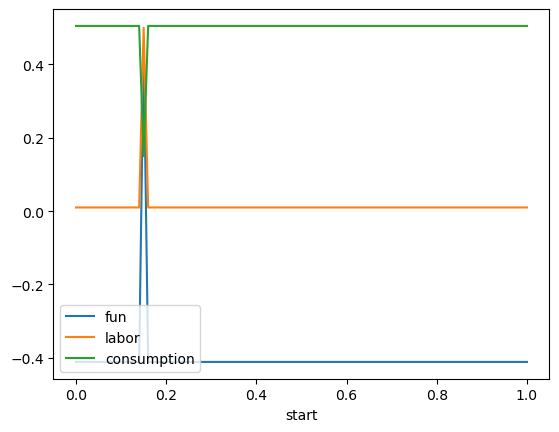

In [5]:
def optimality_test(wealth, salary):
    def disutility(xs):
        labor, consumption = xs
        return -utility(wealth, salary, labor, consumption)
    
    result = []
    for c0 in np.linspace(0, salary, 101):
        optimal = opt.minimize(disutility, (0.5, c0), bounds=[(0.01, 0.999), (0, None)])
        result.append({"start": c0, "fun": disutility(optimal.x), "labor": optimal.x[0], "consumption": optimal.x[1]})
    return pd.DataFrame(result)

df = optimality_test(0.0, 1.0)
df.plot(x="start", y=["fun", "labor", "consumption"])

In [11]:
wealths = np.linspace(0, 10, 101)
salaries = np.linspace(0, 10, 101)
pairs = np.array(np.meshgrid(wealths, salaries)).T.reshape(-1, 2)

df = pd.DataFrame(optimality(x, y) for (x, y) in tqdm.tqdm(pairs))
df.loc[:, "salary"] = pairs[:, 0]
df.loc[:, "wealth"] = pairs[:, 1]

  0%|          | 0/10201 [00:00<?, ?it/s]

/var/folders/s6/w2v5p3l12nv4jz0cy2bqmqq00000gn/T/ipykernel_48645/3424309921.py:5: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(1 + wealth)
/var/folders/s6/w2v5p3l12nv4jz0cy2bqmqq00000gn/T/ipykernel_48645/3424309921.py:11: RuntimeWarning: divide by zero encountered in double_scalars
  return 1/(1 - labor)
/Users/rafael.calsaverini/miniforge3/envs/sandbox/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


<AxesSubplot: xlabel='wealth', ylabel='salary'>

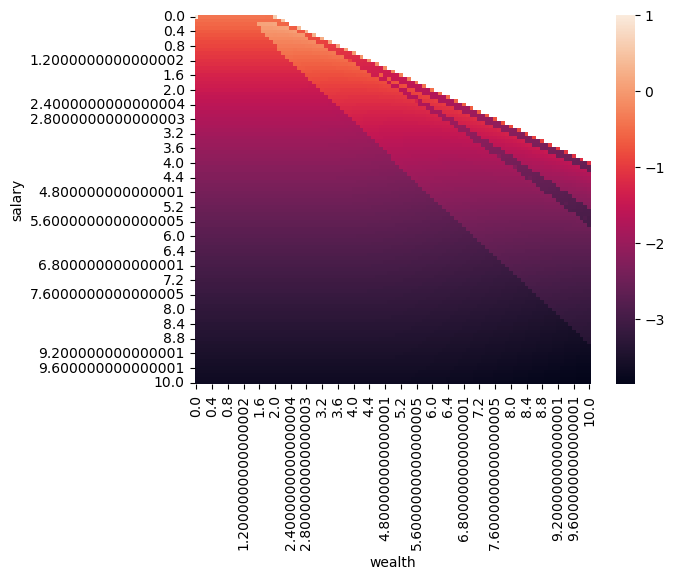

In [25]:
sns.heatmap(df.pivot(index="salary", columns="wealth", values="utility"))